Current Folder:
C:\Users\KPRCAS

Files Available:
['.anaconda', '.aws', '.codeium', '.conda', '.continuum', '.devin', '.idlerc', '.ipynb_checkpoints', '.ipython', '.jupyter', '.kiro', '.matplotlib', '.spyder-py3', '.virtual_documents', '.vscode', '.vscode-shared', 'AppData', 'Application Data', 'Contacts', 'Cookies', 'Desktop', 'Documents', 'Downloads', 'Favorites', 'Francis Tenika_Walmart_.ipynb', 'Jedi', 'Links', 'Local Settings', 'Music', 'My Documents', 'NetHood', 'NTUSER.DAT', 'ntuser.dat.LOG1', 'ntuser.dat.LOG2', 'NTUSER.DAT{e14287cf-f28b-11ef-9cdf-d9fab5b9d2bf}.TM.blf', 'NTUSER.DAT{e14287cf-f28b-11ef-9cdf-d9fab5b9d2bf}.TMContainer00000000000000000001.regtrans-ms', 'NTUSER.DAT{e14287cf-f28b-11ef-9cdf-d9fab5b9d2bf}.TMContainer00000000000000000002.regtrans-ms', 'ntuser.ini', 'OneDrive', 'Pictures', 'PrintHood', 'Recent', 'Saved Games', 'Searches', 'SendTo', 'Start Menu', 'Templates', 'Untitled Folder', 'Videos']
Missing Values Before Treatment
Store           1
Date            0
We

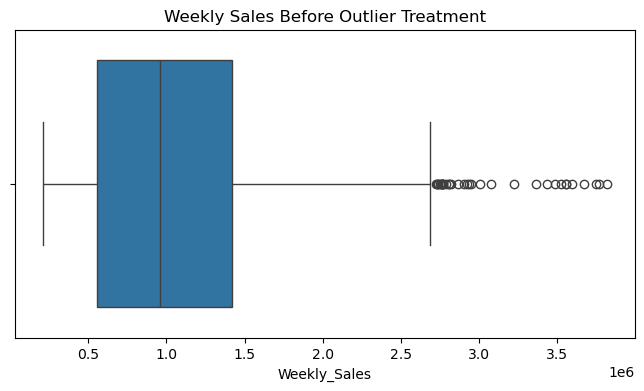

Shape Before: (6434, 13)
Shape After: (6430, 13)
Temperature Max : 100.14
Fuel Price Max : 4.468
CPI Max : 227.2328068
Unemployment Max : 11.218499999999999


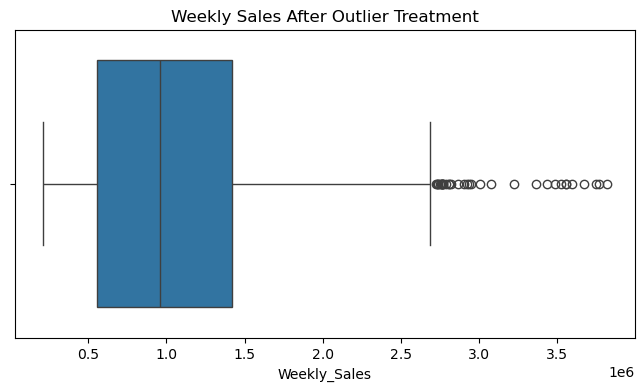

In [5]:
import pandas as pd
from sklearn.impute import SimpleImputer 
df = pd.read_csv(r"C:\Users\KPRCAS\Documents\Walmart[1].csv")
import os

print("Current Folder:")
print(os.getcwd())

print("\nFiles Available:")
print(os.listdir())
print("Missing Values Before Treatment")
print(df.isnull().sum())
num_cols = ['Store','Temperature','Fuel_Price','CPI','Unemployment']

num_imputer = SimpleImputer(strategy='median')
df[num_cols] = num_imputer.fit_transform(df[num_cols])
cat_cols = [
       'Holiday_Flag',
       'Company'
]

cat_imputer = SimpleImputer(strategy='most_frequent')
df[cat_cols] = cat_imputer.fit_transform(df[cat_cols])
print("\nMissing Values After Treatment")
print(df.isnull().sum())
print("\nTotal Missing Values:",
       df.isnull().sum().sum())

print("Shape Before Removing Duplicates:", df.shape)

duplicate_count = df.duplicated().sum()
print("Total Duplicate Rows:", duplicate_count)

df = df.drop_duplicates()

print("Shape After Removing Duplicates:", df.shape)

print(df.dtypes)
df['Store'] = df['Store'].astype(int)
df['Date'] = pd.to_datetime(df['Date'],format='%d-%m-%Y')

df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month

print("\nUpdated Data Types:")
print(df.dtypes)

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['Holiday_Flag_Encoded'] = le.fit_transform(df['Holiday_Flag'])

df['Holiday_Flag_Decoded'] = le.inverse_transform(
                                df['Holiday_Flag_Encoded'])

print(df[['Holiday_Flag',
          'Holiday_Flag_Encoded',
          'Holiday_Flag_Decoded']].head(10))

outlier_cols = [
    'Weekly_Sales',
    'Temperature',
    'Fuel_Price',
    'CPI',
    'Unemployment'
]

for col in outlier_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    outliers = df[
        (df[col] < lower_limit) |
        (df[col] > upper_limit)
    ]

    print(f"{col} : {len(outliers)} outliers")

    import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))

sns.boxplot(x=df['Weekly_Sales'])

plt.title("Weekly Sales Before Outlier Treatment")

plt.show()

print("Shape Before:", df.shape)
df = df[df['Temperature'] <= 200]
df = df[df['Fuel_Price'] <= 10]

df = df[df['CPI'] <= 500]

Q1 = df['Unemployment'].quantile(0.25)
Q3 = df['Unemployment'].quantile(0.75)

IQR = Q3 - Q1

upper_limit = Q3 + (1.5 * IQR)

df['Unemployment'] = df['Unemployment'].clip(
                        upper=upper_limit)

print("Shape After:", df.shape)

print("Temperature Max :", df['Temperature'].max())
print("Fuel Price Max :", df['Fuel_Price'].max())
print("CPI Max :", df['CPI'].max())
print("Unemployment Max :", df['Unemployment'].max())
plt.figure(figsize=(8,4))

sns.boxplot(x=df['Weekly_Sales'])

plt.title("Weekly Sales After Outlier Treatment")

plt.show()
